 # Import libraries and load dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [12]:
df=pd.read_csv("diminos_Data.csv")
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [11]:
df.tail()

,order_id,order_placed_at,order_delivered_at
14995,1538106,2023-03-27 23:37:05,2023-03-27 23:52:37.409378
14996,1538107,2023-03-27 23:47:38,2023-03-28 00:04:22.672912
14997,1538108,2023-03-27 23:50:16,2023-03-28 00:05:40.676238
14998,1538109,2023-03-27 23:52:44,2023-03-28 00:08:41.810358
14999,1538110,2023-03-27 23:58:20,2023-03-28 00:13:42.499311


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            15000 non-null  int64 
 1   order_placed_at     15000 non-null  object
 2   order_delivered_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


# Checking missing values

In [14]:
df.isnull().sum()

order_id              0
order_placed_at       0
order_delivered_at    0
dtype: int64

# Checking duplicate values

In [18]:
print("no. of duplicate rows=",df.duplicated().sum())

no. of duplicate rows= 0


# converting datatype

In [19]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            15000 non-null  int64         
 1   order_placed_at     15000 non-null  datetime64[ns]
 2   order_delivered_at  15000 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1)
memory usage: 351.7 KB


# calculating delivery time in minutes

In [21]:
df['delivery_time_mints']=(df['order_delivered_at']-df['order_placed_at']).dt.total_seconds()/60

In [22]:
df.head()

,order_id,order_placed_at,order_delivered_at,delivery_time_mints
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984


In [25]:
df[['delivery_time_mints']].describe()

,delivery_time_mints
count,15000.000000
mean,20.499389
std,96.160362
min,15.000010
25%,15.274826
50%,15.797986
75%,17.279661
max,7299.831375


# Check SLA (31 minutes)

In [27]:
df['sla_breached']=df['delivery_time_mints']>31
df['sla_breached'].value_counts(normalize=True)*100

sla_breached
False    96.286667
True      3.713333
Name: proportion, dtype: float64

In [36]:
p50 = df['delivery_time_mints'].quantile(0.50)
p90 = df['delivery_time_mints'].quantile(0.90)
p95 = df['delivery_time_mints'].quantile(0.95)
p99 = df['delivery_time_mints'].quantile(0.99)
print(p50)
print(p90)
print(p95)
print(p99)

15.797986066666667
21.156904555
27.261043996666658
65.06418646900005


# Histogram of delivery time 

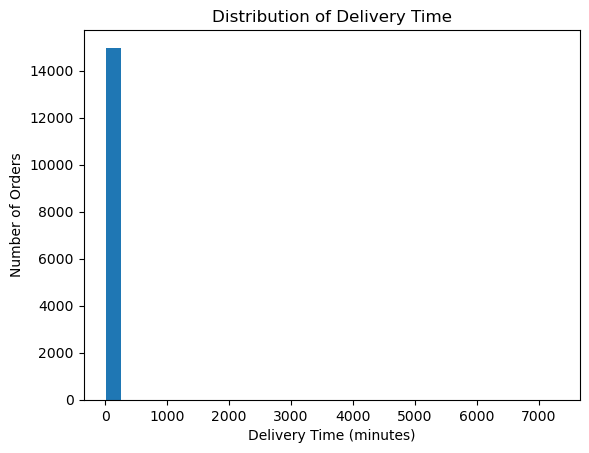

In [33]:
plt.figure()
plt.hist(df['delivery_time_mints'], bins=30)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Time")
plt.show()

# Orders over time

In [37]:
df['order_hour'] = df['order_placed_at'].dt.hour
orders_by_hour = df['order_hour'].value_counts().sort_index()

In [38]:
df.head()

,order_id,order_placed_at,order_delivered_at,delivery_time_mints,sla_breached,order_hour
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719,False,0
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754,False,0
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856,False,0
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657,True,0
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984,False,0


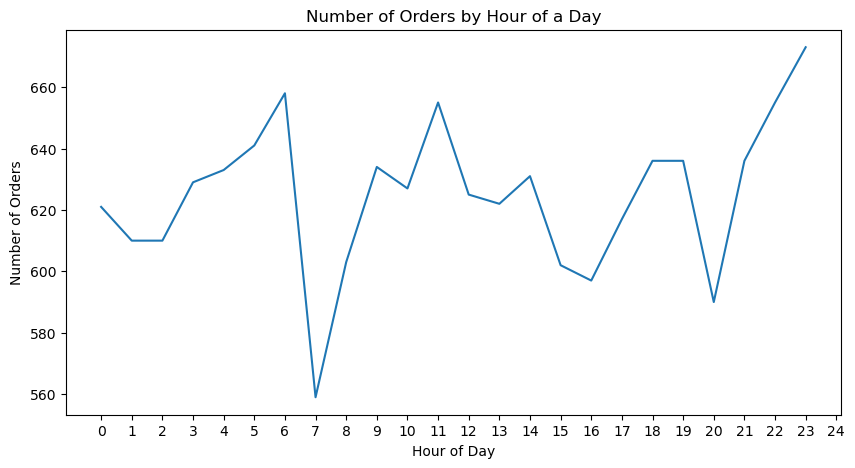

In [43]:
plt.figure(figsize=(10,5))
sns.lineplot(x=orders_by_hour.index, y=orders_by_hour.values)
plt.title('Number of Orders by Hour of a Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 25)) 
plt.show()

# hourly order pattern

In [44]:
df['order_hour'] = df['order_placed_at'].dt.hour

In [45]:
hourly_orders = df.groupby('order_hour')['order_id'].count()
hourly_orders

order_hour
0     621
1     610
2     610
3     629
4     633
5     641
6     658
7     559
8     603
9     634
10    627
11    655
12    625
13    622
14    631
15    602
16    597
17    617
18    636
19    636
20    590
21    636
22    655
23    673
Name: order_id, dtype: int64

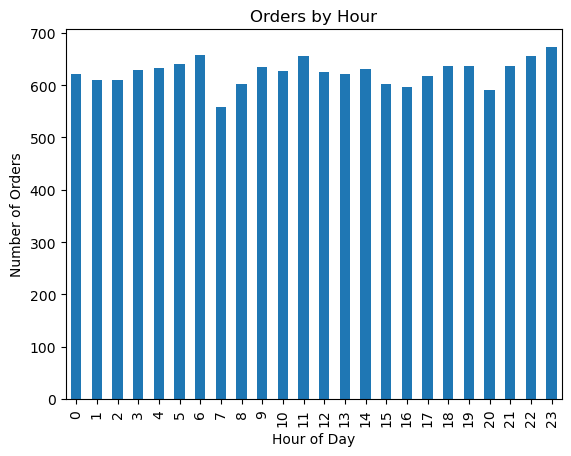

In [48]:
plt.figure()
hourly_orders.plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Hour")
plt.show()

# Worst performing orders

In [49]:
df.sort_values('delivery_time_mints', ascending=False).head(10)

,order_id,order_placed_at,order_delivered_at,delivery_time_mints,sla_breached,order_hour
5499,1528610,2023-03-10 17:06:22,2023-03-15 18:46:11.882496,7299.831375,True,17
4165,1527276,2023-03-08 09:46:43,2023-03-12 11:34:09.085175,5867.434753,True,9
10225,1533336,2023-03-19 11:07:32,2023-03-22 13:53:25.472592,4485.891210,True,11
14155,1537266,2023-03-26 09:54:24,2023-03-29 02:42:50.645252,3888.444088,True,9
10007,1533118,2023-03-19 00:56:34,2023-03-21 00:59:41.454974,2883.124250,True,0
11944,1535055,2023-03-22 12:50:53,2023-03-23 08:03:40.654492,1152.794242,True,12
1361,1524472,2023-03-03 10:04:13,2023-03-04 03:51:02.368715,1066.822812,True,10
5109,1528220,2023-03-10 01:04:58,2023-03-10 14:13:37.181329,788.653022,True,1
117,1523228,2023-03-01 04:59:04,2023-03-01 18:06:52.046891,787.800782,True,4
1910,1525021,2023-03-04 10:41:17,2023-03-04 23:20:15.509579,758.975160,True,10


# Day Vs Night performance

In [51]:
df['day_period'] = np.where(df['order_hour'].between(10, 22),'Day','Night')
df.groupby('day_period')['delivery_time_mints'].quantile(0.95)

day_period
Day      27.617002
Night    26.849865
Name: delivery_time_mints, dtype: float64

In [55]:
summary = pd.DataFrame({'Metric': ['Average', 'Median', '90th Percentile', '95th Percentile', '99th Percentile'],'Delivery Time (mins)': [df.delivery_time_mints.mean(), p50, p90, p95, p99]})
summary

,Metric,Delivery Time (mins)
0,Average,20.499389
1,Median,15.797986
2,90th Percentile,21.156905
3,95th Percentile,27.261044
4,99th Percentile,65.064186


# Insights
#### >Kanav’s store meets SLA today, but sustained compliance depends on controlling peak-hour and outlier delays rather than improving average delivery time.